### Implement ReAct with LangGraph-What is ReAct?

ReAct (Reasoning + Acting) is a framework where an LLM:
* Reasons step-by-step (e.g. decomposes questions, makes decisions)
* Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG: Think → Retrieve → Observe → Reflect → Final Answer

In [4]:
import os
from typing import Annotated, TypedDict, Sequence

from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

# Core tool and message imports
from langchain_core.tools import Tool, tool
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# Community tools, utilities, and loaders
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader

# Embeddings and text splitters
from langchain_openai import OpenAIEmbeddings  # or from langchain_community.embeddings import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings

In [6]:

# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
# embedding = OpenAIEmbeddings()

embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [8]:
retriever.invoke("What are automous agents.")

[Document(id='38e4f9a3-e4a6-4ad7-b84b-147c335ad778', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [11]:
def retriever_tool_func(query:str) ->str:
    print("Using RAGRtriever tool ")
    docs =  retriever.invoke(query) 
    return "\n" .join([doc.page_content for doc in docs])

In [12]:
retriever_tool_func("What are autonomous agents")

Using RAGRtriever tool 


"Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\nTool use\n\nThe agent learns to call external APIs for extra information that is missing from the model weights (often hard to change after pre-training), including current information, code execution capability, access to proprietary information sources and more.\n\n\n\n\n\nOverview of a LLM-powered autonomous agent system.\nPlanning is essentially in order to optimize believability at the moment vs in time.\nPrompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 1)\nRelat

In [15]:

retriever_tool=Tool(
name="RAGRetriever",
description="Use this tool to fetch relevant knowledge base info",
func=retriever_tool_func
)
retriever_tool
print(retriever_tool.name)

RAGRetriever


In [16]:
# Wikipedia tool 
wiki_tool  = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper()) 
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\rajna\\.conda\\envs\\udemy\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

In [35]:
import os 
from langchain_groq import ChatGroq

from dotenv import load_dotenv
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm=ChatGroq(model="openai/gpt-oss-safeguard-20b")

C:\Users\rajna\AppData\Local\Temp\ipykernel_23092\1906797949.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node =  create_react_agent(llm,tools)


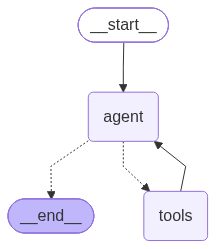

In [36]:
# define the agaent node 
tools =  [retriever_tool,wiki_tool] 
## create the native Langgraph react agent 
react_node =  create_react_agent(llm,tools)
react_node

In [37]:
#
# 3. LangGraph Agent State
#
class AgentState(TypedDict):
    messages: Annotated [Sequence [BaseMessage], add_messages]

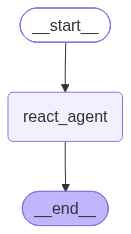

In [38]:
# Build LangGraph Graph 
builder = StateGraph(AgentState)
builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)
graph = builder.compile()
graph

In [39]:
user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
state = {"messages": [HumanMessage(content=user_query)]}

result = graph.invoke(state)
print("\n\nFinal Answer:\n", result["messages"][-1].content)


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [25]:
# 5. Run the ReAct Agent

if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = graph.invoke(state)
    print(f"\n\n Final Answer:\n", result["messages"][-1].content)


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

# Tool creation for RAG agents with langgraph

To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:
* RAG retrieval
* Search
* Wikipedia
* SQL
* Web APIs
* Calculators, etc.




### Tool Design Requirements
A LangGraph tool must:
* Have a name
* Have a description (used by the LLM to decide when to use it)
* Have a callable func, accepting a single input (usually str) and returning str

In [43]:

import os
from typing import Annotated, Sequence, TypedDict
from langchain_core.tools import Tool, tool
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader, ArxivLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages


In [44]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'Safety GPT OSS 20B', 'release_date': '2025-03-05', 'last_updated': '2025-03-05', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000014E0265BC90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000014E0265A950>, model_name='openai/gpt-oss-safeguard-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [47]:
### Generic funcation to create a retirveral tools
### Generic function to create a retireval tool
def make_retriever_tool_from_text(file,name,desc):
    docs-TextLoader (file, encoding="utf-8").load()  
    chunks=  RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents (docs)
    vs= FAISS.from_documents (chunks, embedding)
    retriever= vs.as_retriever()
    
    def tool_func(query:str) ->str:
        print(f"using tool:{name}") 
        result = retriever.invoke(query) 
        return "\n\n".join(doc.page_content for doc in result)
    return Tool(name=name,description=desc,func=tool_func)


In [50]:
# Instantiate the Wikipedia wrapper and tool
wiki = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

# Wikipedia Tool
wiki_tool = Tool(
    name="Wikipedia",
    description="Use this tool to fetch general world knowledge from Wikipedia.",
    func=wiki.run  # <-- Changed from 'wiki' to 'wiki.run'
)

# ArXiv Tool
def arxiv_search(query: str) -> str:
    print(" Searching ArXiv...")
    results = ArxivLoader(query).load()
    return "\n\n".join(doc.page_content[:1000] for doc in results[:2]) or "No papers found."


arxiv_tool = Tool(
    name="ArxivSearch",
    description="Use this tool to fetch recent academic papers on technical topics.",
    func=arxiv_search
)


In [ ]:

internal_tool_1=make_retriever_tool_from_text(
"internal_docs.txt",
"InternalTechDocs",
"Search internal tech documents for proprietary architecture and methods."
)
internal_tool_1

RuntimeError: Error loading internal_docs.txt

In [ ]:

internal_tool_2 = make_retriever_tool_from_text(
    "research_notes.txt",
    "InternalResearchNotes",
    "Search internal research notes for experimental results and agent designs."
)
internal_tool_2


In [52]:
tools = [wiki_tool,arxiv_tool,internal_tool_1,internal_tool_2]

react_node= create_react_agent(llm,tools)
react_node

NameError: name 'internal_tool_1' is not defined

In [ ]:

query = "what do our internal research notes say about transformer variants, and what does ArXiv suggest recently?"
state = {"messages": [HumanMessage(content=query)]}
result = graph.invoke(state)
print("\n Final Answer: \n", result["messages"][-1].content)
